# NLP with Disaster Tweets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import warnings 
warnings.filterwarnings('ignore')

from textblob import TextBlob
import nltk
from nltk.corpus import stopwords


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (7613, 5)
Test shape: (3263, 4)


In [7]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [8]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [9]:
df=pd.concat([train,test]) 

# EDA

In [10]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1.0
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1.0
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1.0
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1.0
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10876 entries, 0 to 3262
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        10876 non-null  int64  
 1   keyword   10789 non-null  object 
 2   location  7238 non-null   object 
 3   text      10876 non-null  object 
 4   target    7613 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 509.8+ KB


In [12]:
df.isnull().sum()

id             0
keyword       87
location    3638
text           0
target      3263
dtype: int64

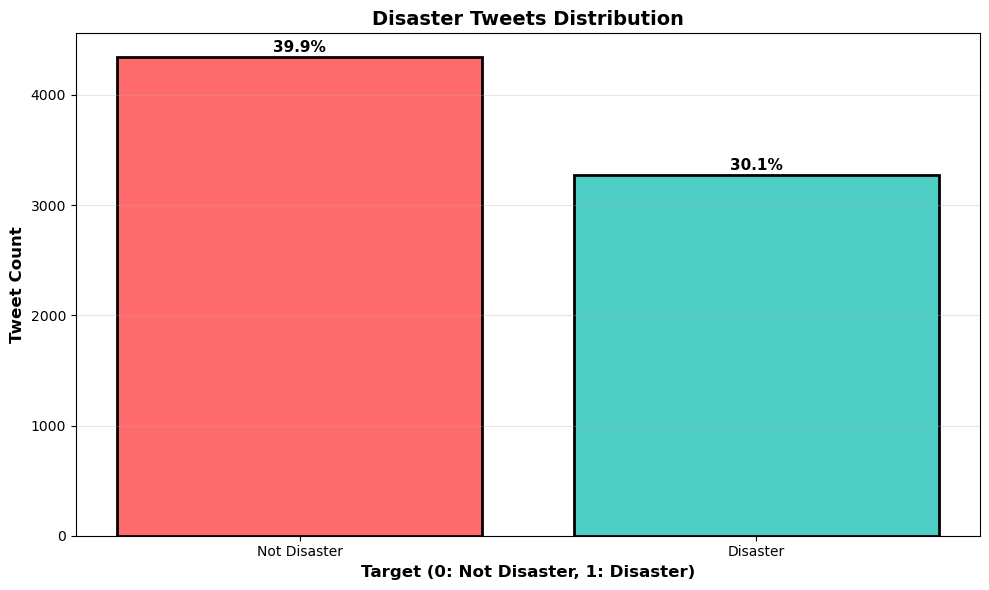

In [13]:
plt.figure(figsize=(10, 6))
target_counts = df['target'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
plt.bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', linewidth=2)
plt.xlabel('Target (0: Not Disaster, 1: Disaster)', fontsize=12, fontweight='bold')
plt.ylabel('Tweet Count', fontsize=12, fontweight='bold')
plt.title('Disaster Tweets Distribution', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Not Disaster', 'Disaster'])
plt.grid(axis='y', alpha=0.3)


# Yüzdelik ekle
for i, (idx, val) in enumerate(target_counts.items()):
    percentage = (val / len(df)) * 100
    plt.text(idx, val + 50, f'{percentage:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

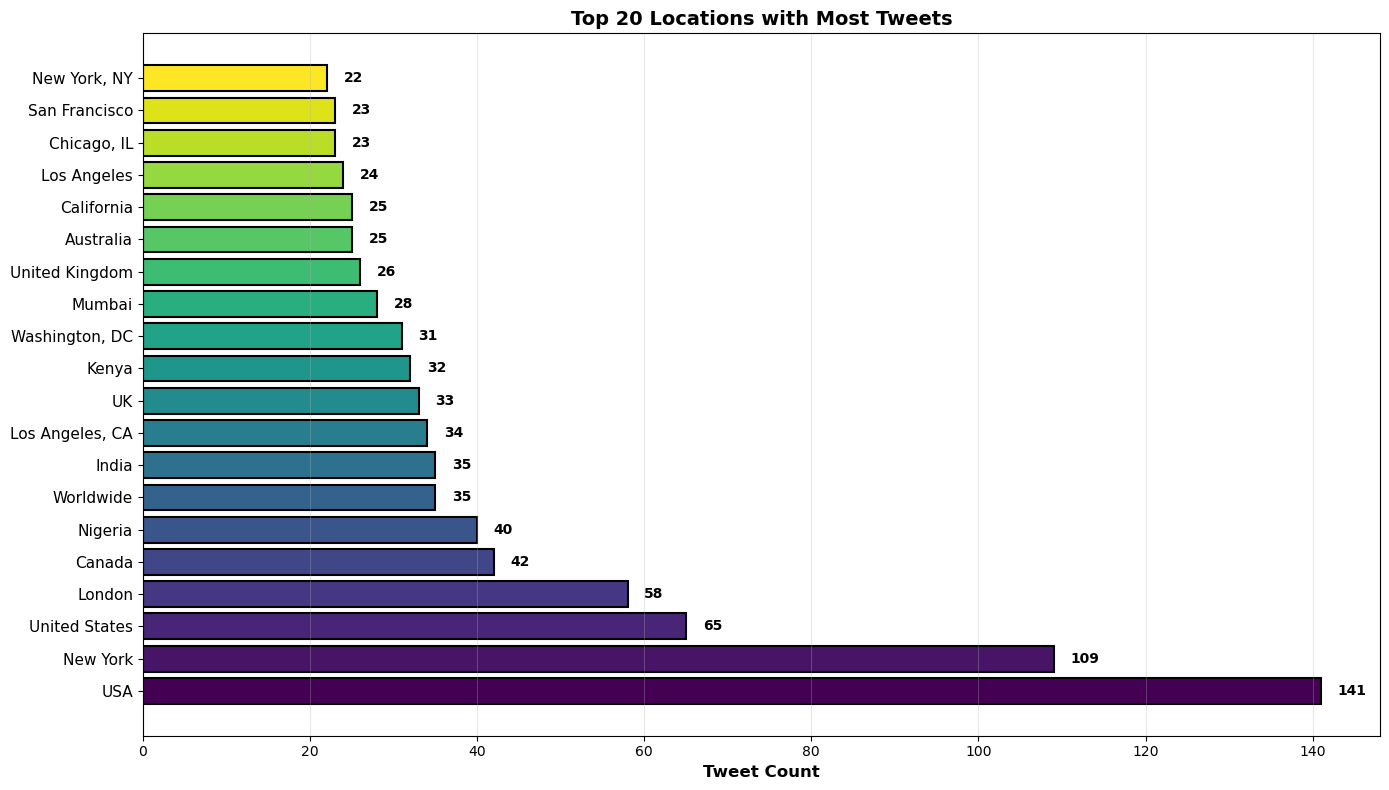

In [14]:
# TOP 20 LOCATIONS
df_location = df[df['location'].notna()]
top_locations = df_location['location'].value_counts().head(20)

plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_locations)))
bars = plt.barh(range(len(top_locations)), top_locations.values, color=colors, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(top_locations)), top_locations.index, fontsize=11)
plt.xlabel('Tweet Count', fontsize=12, fontweight='bold')
plt.title('Top 20 Locations with Most Tweets', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Değerleri göster
for i, (idx, val) in enumerate(top_locations.items()):
    plt.text(val + 2, i, str(val), va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

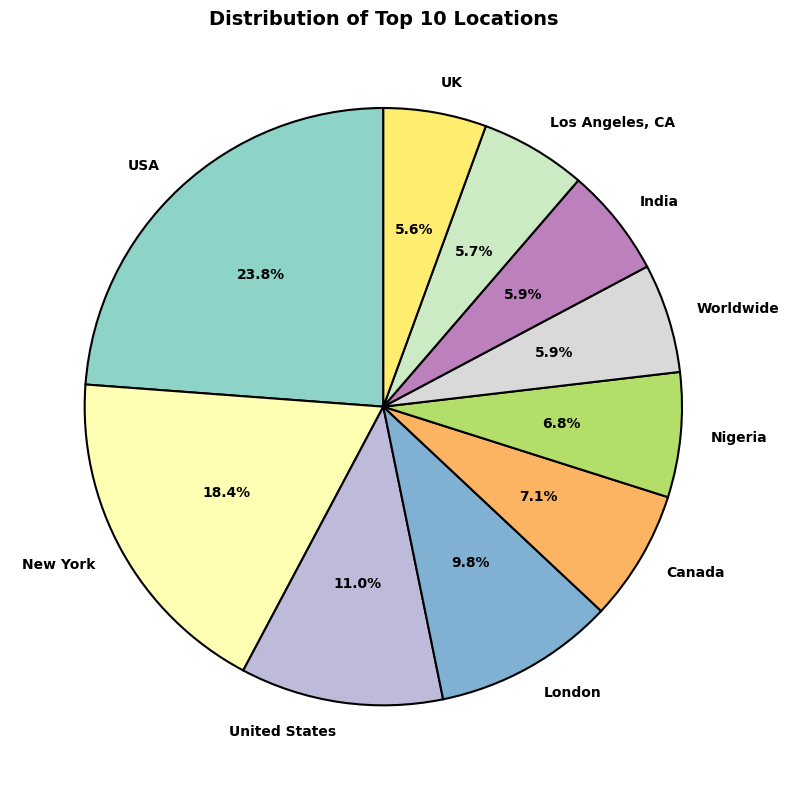

In [15]:
# TOP 10 LOCATIONS 
plt.figure(figsize=(12, 8))
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(top_locations.head(10))))
plt.pie(top_locations.head(10).values, 
        labels=top_locations.head(10).index, 
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

plt.title('Distribution of Top 10 Locations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

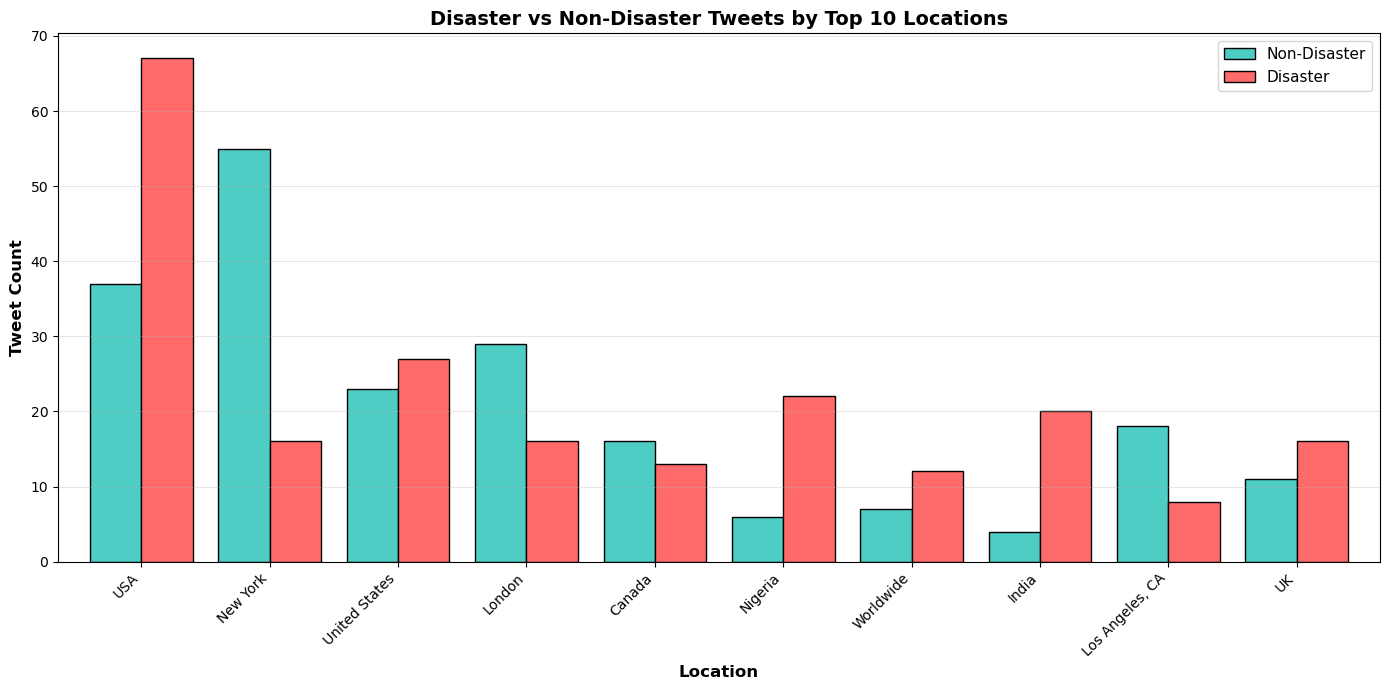

In [16]:
# Disaster vs Non-Disaster Tweets by Top 10 Locations
top_locs = df_location['location'].value_counts().head(10).index

# Lokasyon ve target'a göre grupla, say
counts = df_location[df_location['location'].isin(top_locs)] \
    .groupby(['location', 'target']).size().unstack(fill_value=0)
counts = counts.reindex(top_locs)

# Grafiği çiz
counts.plot(kind='bar', figsize=(14, 7), 
            color=['#4ECDC4', '#FF6B6B'], edgecolor='black', width=0.8)

plt.title('Disaster vs Non-Disaster Tweets by Top 10 Locations', fontsize=14, fontweight='bold')
plt.xlabel('Location', fontsize=12, fontweight='bold')
plt.ylabel('Tweet Count', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(['Non-Disaster', 'Disaster'], fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Feature Engineering

In [17]:
df = df.drop(['id','keyword', 'location'], axis=1)

In [18]:
df.head()

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1.0
1,Forest fire near La Ronge Sask. Canada,1.0
2,All residents asked to 'shelter in place' are ...,1.0
3,"13,000 people receive #wildfires evacuation or...",1.0
4,Just got sent this photo from Ruby #Alaska as ...,1.0


In [ ]:
from langdetect import detect
df["language"] = df["text"].apply(detect)

In [ ]:
df["language"].value_counts()

In [ ]:
#df = df[df["language"] == 'en']
#df=df.reset_index(drop=True)

In [19]:
df['text']=df['text'].str.lower() # küçük harfe çeviriyor
df['text']=df['text'].str.replace('[^\w\s]','', regex=True) # noktolama işaretlerini kaldırır
df['text']=df['text'].str.replace('\d+','', regex=True) # rakamları kaldırır
df['text']=df['text'].str.replace('\n','', regex=True) # satır sonlarını kaldırır
df['text']=df['text'].str.replace('\r','', regex=True) # enter'ları kaldırıyor

In [20]:
train_df = df[df['target'].notna()]
test_df = df[df['target'].isna()]

In [31]:
x = train_df.drop(['target'], axis=1) 
y = train_df['target']

In [32]:
x.shape

(7613, 1)

In [33]:
x.head()

,text
0,our deeds are the reason of this earthquake ma...
1,forest fire near la ronge sask canada
2,all residents asked to shelter in place are be...
3,people receive wildfires evacuation orders in...
4,just got sent this photo from ruby alaska as s...


In [34]:
y.head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: target, dtype: float64

In [35]:
# NLTK durak kelimeleri indir
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
def ekkok(text):
    words = TextBlob(text).words
    return [word.lemmatize() for word in words if word.lower() not in stop_words]

In [37]:
vect=CountVectorizer()

In [40]:
vect = CountVectorizer(ngram_range=(1, 2), analyzer=ekkok, stop_words='english')

In [41]:
x_vect = vect.fit_transform(x).toarray()

In [42]:
x_vect

array([[1]])